# Exploratory Data Analysis (EDA)

Analyze the cleaned Steam games data to understand distributions, correlations, and patterns related to success.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_games.csv')
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DLC count,Supported languages,Windows,...,Publishers,Categories,Genres,owners_low,owners_high,owners_mid,high_owners,high_score,high_ccu,successful
0,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0 - 20000,0,0,5.24,0,['English'],True,...,['MangaGamer'],"['Single-player', 'Steam Trading Cards', 'Stea...",['Adventure'],0,20000,10000.0,False,False,False,False
1,1034400,Mystery Solitaire The Black Raven,2019-05-06,0 - 20000,0,0,4.99,0,"['English', 'French', 'German', 'Russian']",True,...,['8floor'],"['Single-player', 'Family Sharing']",['Casual'],0,20000,10000.0,False,False,False,False
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,0 - 20000,1,0,8.99,1,['Korean'],True,...,['유진게임즈'],"['Single-player', 'Steam Achievements', 'Famil...","['Casual', 'Indie', 'Simulation']",0,20000,10000.0,False,False,False,False
3,3631080,Maze Quest VR,2025-04-24,0 - 20000,0,0,4.99,0,['English'],True,...,['Reality Expanded LLC'],"['Single-player', 'VR Only', 'Steam Leaderboar...","['Action', 'Early Access']",0,20000,10000.0,False,False,False,False
4,1654170,Agony VR,2023-04-05,0 - 20000,0,0,13.99,0,"['English', 'French', 'Italian', 'German', 'Sp...",True,...,"['Ignibit', 'Madmind Studio']","['Single-player', 'Tracked Controller Support'...","['Action', 'Adventure']",0,20000,10000.0,False,False,False,False


In [2]:
# Basic statistics
df.describe()

,AppID,Peak CCU,Required age,Price,DLC count,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Median playtime forever,owners_low,owners_high,owners_mid
count,1.009700e+05,1.009700e+05,100970.000000,100970.000000,100970.000000,100970.000000,100970.000000,1.009700e+05,1.009700e+05,100970.000000,1.009700e+05,1.009700e+05,1.009700e+05,1.009700e+05,1.009700e+05,1.009700e+05
mean,1.772874e+06,6.629436e+01,0.198128,5.282897,0.620650,3.099594,0.029811,1.268959e+03,2.054617e+02,20.544488,1.164998e+03,2.526090e+02,2.107721e+02,6.073755e+04,1.474466e+05,1.040921e+05
std,1.017109e+06,4.109641e+03,1.796800,11.784509,15.969311,14.964016,1.537085,3.095159e+04,5.922057e+03,155.464887,2.410407e+04,1.236107e+04,1.234452e+04,9.205191e+05,1.922967e+06,1.420515e+06
min,1.000000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+04,1.000000e+04
25%,9.173125e+05,0.000000e+00,0.000000,0.990000,0.000000,0.000000,0.000000,1.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+04,1.000000e+04
50%,1.636110e+06,0.000000e+00,0.000000,2.990000,0.000000,0.000000,0.000000,1.000000e+01,2.000000e+00,6.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+04,1.000000e+04
75%,2.564868e+06,0.000000e+00,0.000000,5.990000,0.000000,0.000000,0.000000,5.900000e+01,1.600000e+01,21.000000,0.000000e+00,6.000000e+00,6.000000e+00,2.000000e+04,5.000000e+04,3.500000e+04
max,4.230400e+06,1.013936e+06,21.000000,999.980000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,9821.000000,4.830455e+06,3.429544e+06,3.429544e+06,1.000000e+08,2.000000e+08,1.500000e+08


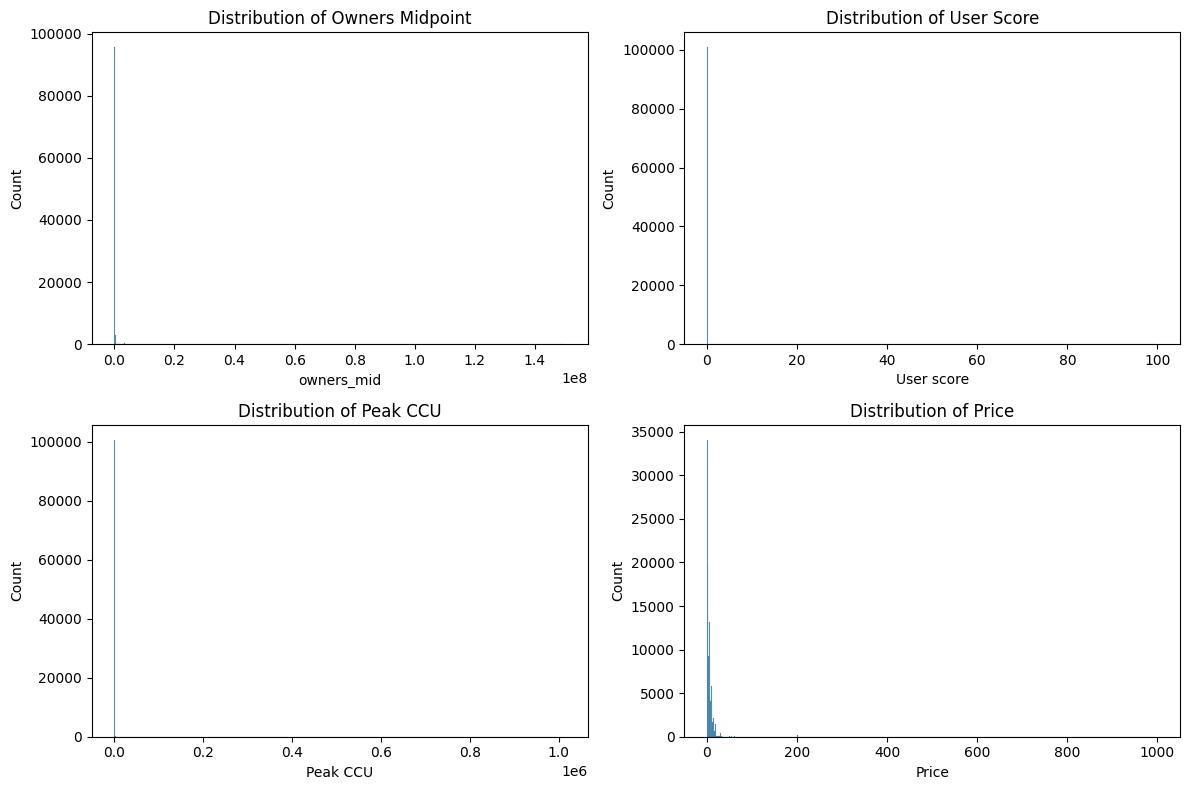

In [4]:
# Distribution of success metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['owners_mid'], ax=axes[0,0])
axes[0,0].set_title('Distribution of Owners Midpoint')
sns.histplot(df['User score'], ax=axes[0,1])
axes[0,1].set_title('Distribution of User Score')
sns.histplot(df['Peak CCU'], ax=axes[1,0])
axes[1,0].set_title('Distribution of Peak CCU')
sns.histplot(df['Price'], ax=axes[1,1])
axes[1,1].set_title('Distribution of Price')
plt.tight_layout()
plt.show()

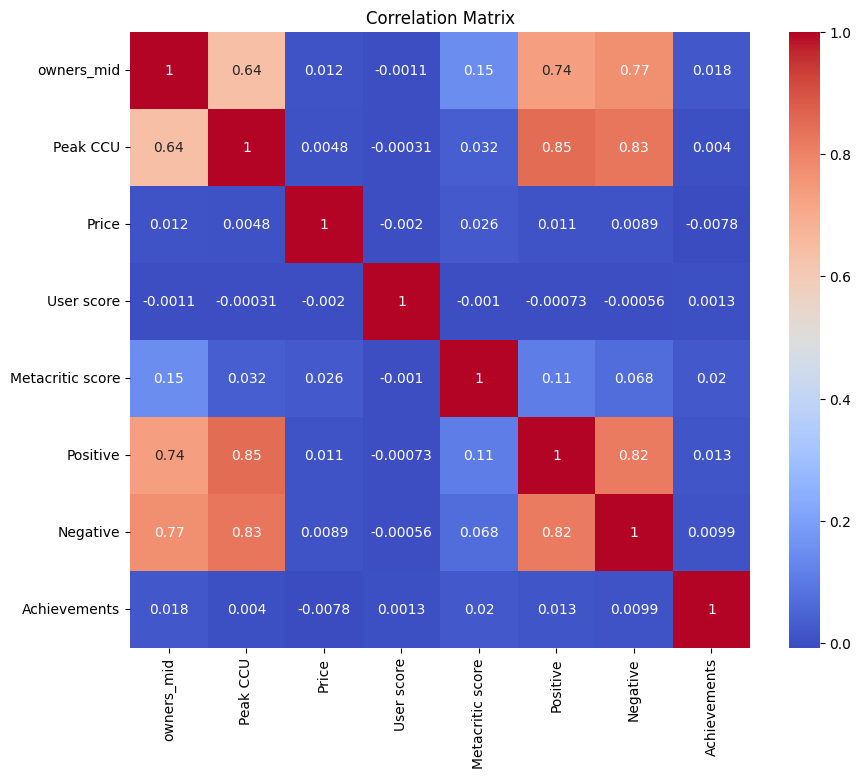

In [5]:
# Correlation heatmap
numeric_cols = ['owners_mid', 'Peak CCU', 'Price', 'User score', 'Metacritic score', 'Positive', 'Negative', 'Achievements']
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

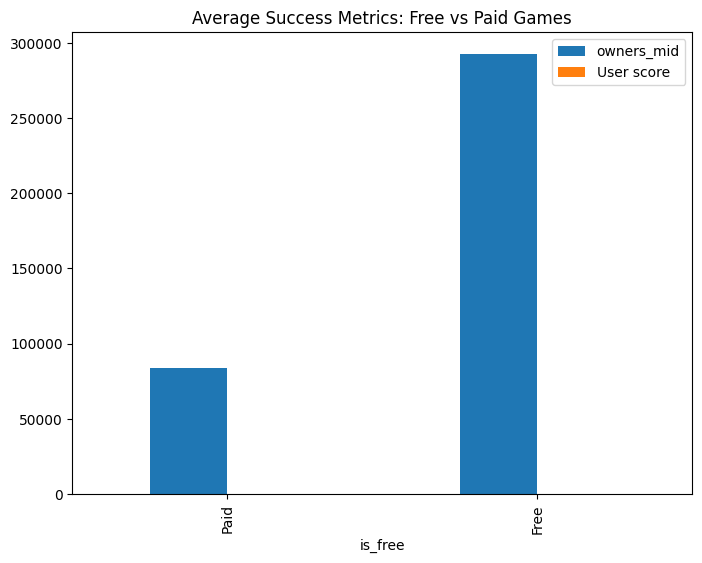

In [6]:
# Free vs Paid analysis
df['is_free'] = df['Price'] == 0
free_paid_success = df.groupby('is_free')[['owners_mid', 'User score']].mean()
free_paid_success.plot(kind='bar', figsize=(8,6))
plt.title('Average Success Metrics: Free vs Paid Games')
plt.xticks([0,1], ['Paid', 'Free'])
plt.show()

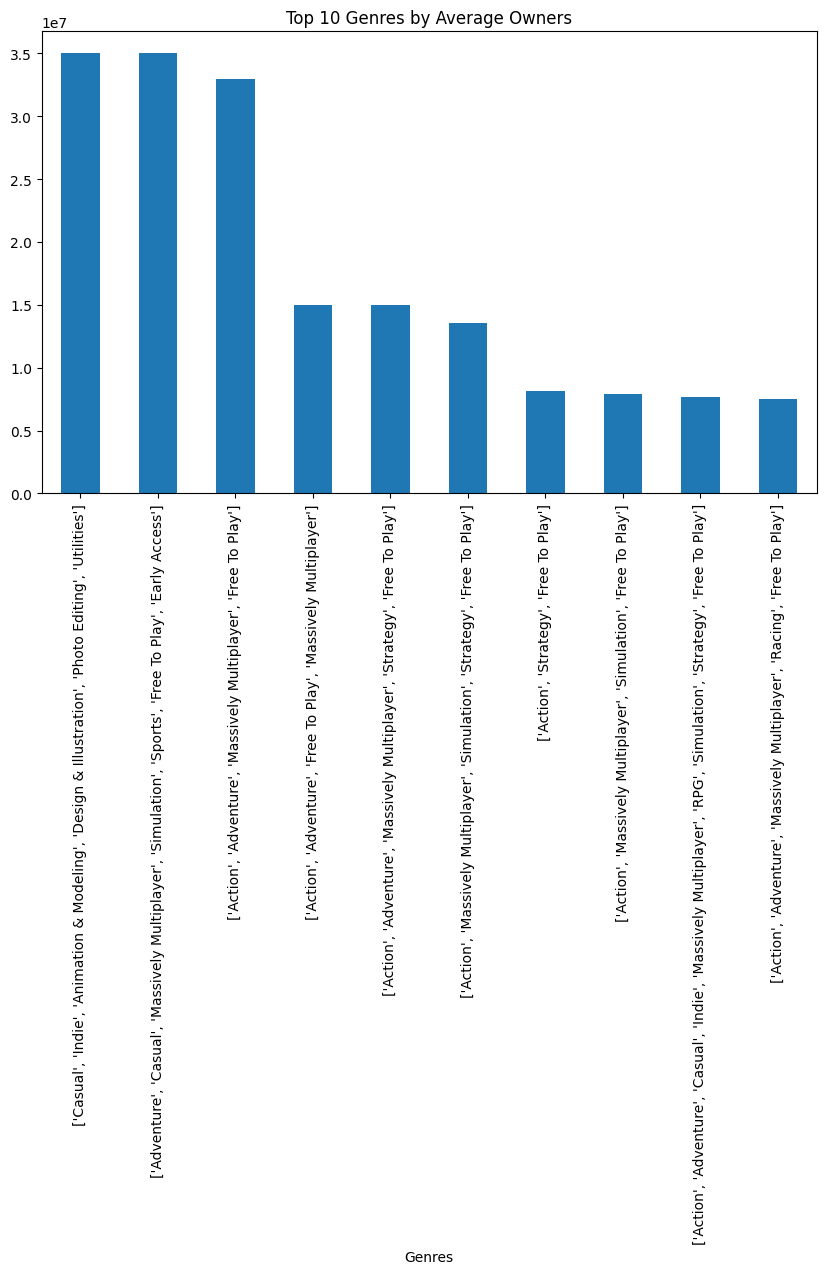

In [7]:
# Top genres by average owners
# Explode genres
df_genres = df.explode('Genres')
genre_success = df_genres.groupby('Genres')['owners_mid'].mean().sort_values(ascending=False).head(10)
genre_success.plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Genres by Average Owners')
plt.show()